# Trying to create and test U net 

# Arborescence de projet

In [1]:
import sys
import os
# On récupère le chemin absolu du dossier parent (..) et on l'ajoute au sys.path
dossier_parent = os.path.abspath('..')
if dossier_parent not in sys.path:
    sys.path.append(dossier_parent)

## Imports

In [2]:
import musdb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchaudio
from u_net import UnetAudioStemmer
from tool_box.pad_or_crop import pad_or_crop_to_multiple
from IPython.display import Audio, display

# GPU Training

In [3]:
# Si tu as une carte NVIDIA (CUDA), ça prendra le GPU. Sur Mac M1/M2/M3, on utilise "mps".
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"L'entraînement se fera sur : {device}")

L'entraînement se fera sur : cuda


## Data

In [ ]:
data_base = "../data/dataset/"
mus = musdb.DB(root=data_base,is_wav=False)
track = mus.tracks[0]
X = torch.from_numpy(track.audio.T)
y = torch.from_numpy(track.targets["vocals"].audio.T)
if X.shape[0] > 1: 
        X = torch.mean(X,dim=0,keepdim=True)
if y.shape[0] > 1: 
        y = torch.mean(y,dim=0,keepdim=True)
sample_rate = track.rate

# On ne prends que 3 secondes du morceau 
X = X[:,30 * sample_rate : 33 * sample_rate]
y = y[:,30 * sample_rate : 33 * sample_rate]
print(f"🎵 Morceau chargé : {track.name}")
print(f"⏱️ Durée : {track.duration} secondes")

display(Audio(X, rate=sample_rate))
display(Audio(y,rate=sample_rate))


44100
44100
🎵 Morceau chargé : A Classic Education - NightOwl
⏱️ Durée : 171.24 secondes


# Constants

In [5]:
n_fft = 2048
hop_length = 512

# STFT Conversion 

In [6]:
X_stft = torch.stft(X,n_fft=n_fft,hop_length=hop_length,return_complex=True).unsqueeze(0)
y_stft = torch.stft(y,n_fft=n_fft,hop_length=hop_length,return_complex=True).unsqueeze(0)
print(X.shape)
X_stft = pad_or_crop_to_multiple(X_stft,multiple=8)
y_stft = pad_or_crop_to_multiple(y_stft,multiple=8)
print(X_stft.shape)

torch.Size([1, 132300])
torch.Size([1, 1, 1024, 256])


c:\Users\ggyor\miniconda3\envs\hf-audio-stem\lib\site-packages\torch\functional.py:704: UserWarning: A window was not provided. A rectangular window will be applied,which is known to cause spectral leakage. Other windows such as torch.hann_window or torch.hamming_window can are recommended to reduce spectral leakage.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\SpectralOps.cpp:842.)
  return _VF.stft(  # type: ignore[attr-defined]


# Passage en DB pour normaliser entre les différents instruments. 

In [7]:
X_db = 20 * torch.log10(torch.abs(X_stft) + 1e-5)
y_db = 20 * torch.log10(torch.abs(y_stft) + 1e-5)
print(X_db.shape)

torch.Size([1, 1, 1024, 256])


# Correction pour normaliser sur les fréquences

In [8]:
X_db = X_db[..., :1024, :]
y_db= y_db[..., :1024, :]
print(X_db.shape)

torch.Size([1, 1, 1024, 256])


# Ajout d'une dimension pour le batch

In [9]:
X_train = X_db.float().to(device=device)
y_train = y_db.float().to(device=device)

print(f"📊 Shape de l'entrée X (Mix) : {X_train.shape}")
print(f"📊 Shape de la cible Y (Voix) : {y_train.shape}")

📊 Shape de l'entrée X (Mix) : torch.Size([1, 1, 1024, 256])
📊 Shape de la cible Y (Voix) : torch.Size([1, 1, 1024, 256])


# Init du modèle

In [10]:
model = UnetAudioStemmer()
model = model.to(device=device)

# Utilisation de la L1 loss et pas la MSE car la L1 permet d'éviter que le modèle se focus sur les grosses valeurs gros pics d'énergie dans la musique alors que nous on veut éliminer le bruit ambiant autour de la voix.
criterion = nn.L1Loss()

# Optimizer 
optimizer = optim.Adam(model.parameters(), lr=0.00095)

# Paramètres de l'entraînement 

In [11]:
epochs = 1000 # On va répéter l'opération 50 fois sur le même extrait

# Entraînement

In [23]:
# Passer le modèle en mode train 
model.train()

for epoch in range(epochs):
    # Reset les gradients d'optimisation 
    optimizer.zero_grad()

    # Inference
    voice_spectogram = model(X_train)

    # Loss 
    loss = criterion(y_train, voice_spectogram)

    # Backward pass
    loss.backward()

    # Model Optimisation 
    optimizer.step()

    # Affichage de la progression tous les 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] - Loss : {loss.item():.4f}")

print("✅ Entraînement terminé !")
voice_spectogram = model(X_train)


Epoch [1/1000] - Loss : 0.9829
Epoch [10/1000] - Loss : 0.9650
Epoch [20/1000] - Loss : 0.9672
Epoch [30/1000] - Loss : 0.9750
Epoch [40/1000] - Loss : 0.9520
Epoch [50/1000] - Loss : 0.9556
Epoch [60/1000] - Loss : 0.9816
Epoch [70/1000] - Loss : 0.9697
Epoch [80/1000] - Loss : 0.9780
Epoch [90/1000] - Loss : 0.9779
Epoch [100/1000] - Loss : 0.9594
Epoch [110/1000] - Loss : 0.9588
Epoch [120/1000] - Loss : 0.9570
Epoch [130/1000] - Loss : 0.9463
Epoch [140/1000] - Loss : 0.9496
Epoch [150/1000] - Loss : 0.9536
Epoch [160/1000] - Loss : 0.9785
Epoch [170/1000] - Loss : 0.9790
Epoch [180/1000] - Loss : 0.9487
Epoch [190/1000] - Loss : 0.9570
Epoch [200/1000] - Loss : 0.9570
Epoch [210/1000] - Loss : 0.9647
Epoch [220/1000] - Loss : 0.9548
Epoch [230/1000] - Loss : 0.9464
Epoch [240/1000] - Loss : 0.9375
Epoch [250/1000] - Loss : 0.9458
Epoch [260/1000] - Loss : 0.9406
Epoch [270/1000] - Loss : 0.9415
Epoch [280/1000] - Loss : 0.9356
Epoch [290/1000] - Loss : 0.9555
Epoch [300/1000] - Lo

# Test du sample

In [24]:
# --- 1. NETTOYAGE DES DIMENSIONS ---
# On enlève les dimensions "Batch" et "Canal"
# Le tenseur passe de [1, 1, 1024, Temps] à [1024, Temps]
voice_spectogram = voice_spectogram.squeeze().to("cpu")
print(voice_spectogram.shape)

# --- 2. RETOUR À L'ÉCHELLE LINÉAIRE ---
# On inverse la formule des décibels ( 20 * log10(x) )
# On utilise detach() pour détacher le tenseur du graphe de calcul de PyTorch
voice_spectrogram_magnitude = 10 ** (voice_spectogram.detach() / 20)

#Récupération de la phase de la voix
y_phase = torch.angle(y_stft).squeeze()
print(y_phase.shape)

# On recrée un tenseur complexe (Magnitude + Phase) avec la formule d'Euler
complex_spec = voice_spectrogram_magnitude * torch.exp(1j * y_phase)

# ⚠️ 2. LA RUSTINE DU 1025 (Le rajout de la fréquence manquante) ⚠️
# complex_spec a la forme [1024, Temps]
# F.pad lit les dimensions à l'envers (de droite à gauche) :
# - Axe du Temps (dernière dimension) : on rajoute 0 avant, 0 après -> (0, 0)
# - Axe des Fréquences (avant-dernière) : on rajoute 0 avant, 1 après -> (0, 1)
complex_spec_padded = F.pad(complex_spec, (0, 0, 0, 1))

# On repasse dans le domaine temporel !
reconstructed_waveform = torch.istft(
    complex_spec_padded, 
    n_fft=n_fft, 
    hop_length=hop_length
)

# --- 6. ÉCOUTE DU RÉSULTAT ---
print("🎧 Résultat de la voix isolée par U-Net :")
# Assure-toi que la variable 'sample_rate' correspond bien à ton fichier audio (ex: 44100)
display(Audio(reconstructed_waveform.numpy(), rate=sample_rate))


torch.Size([1024, 256])
torch.Size([1024, 256])
🎧 Résultat de la voix isolée par U-Net :


# Comparaison spectro

In [ ]:
import matplotlib.pyplot as plt

## Test

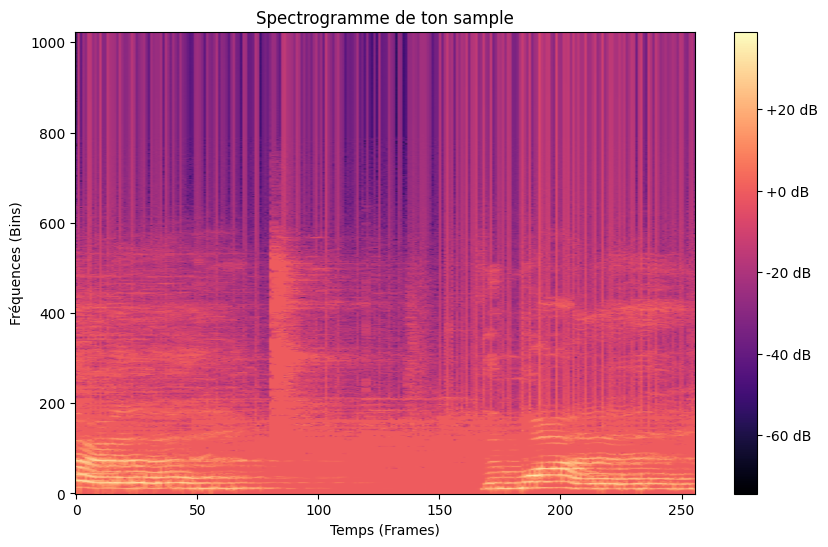

Dimension de l'image (Tenseur) : torch.Size([1024, 256])


In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(voice_spectogram.detach(), origin='lower', aspect='auto', cmap='magma')
plt.title("Spectrogramme de ton sample")
plt.xlabel("Temps (Frames)")
plt.ylabel("Fréquences (Bins)")
plt.colorbar(format="%+2.0f dB")
plt.show()
print(f"Dimension de l'image (Tenseur) : {voice_spectogram.shape}")

## Vérité terrain

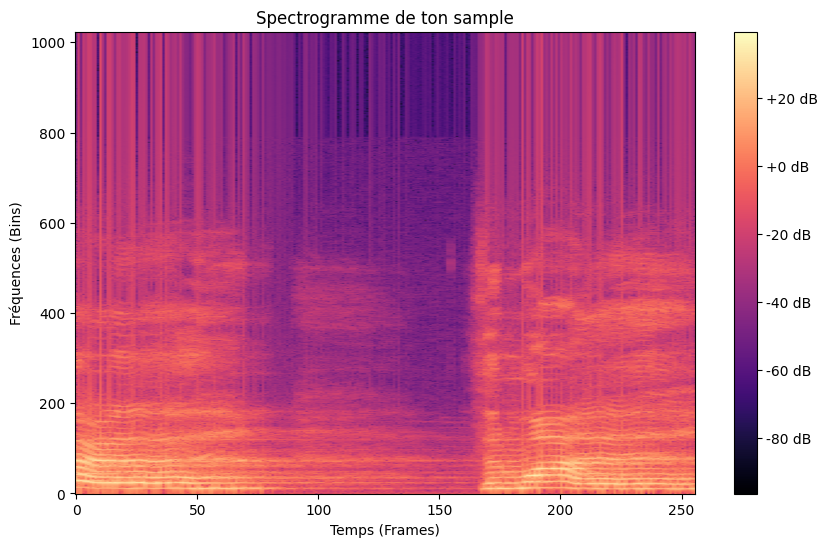

Dimension de l'image (Tenseur) : torch.Size([1024, 256])


In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(y_train.squeeze().detach(), origin='lower', aspect='auto', cmap='magma')
plt.title("Spectrogramme de ton sample")
plt.xlabel("Temps (Frames)")
plt.ylabel("Fréquences (Bins)")
plt.colorbar(format="%+2.0f dB")
plt.show()
print(f"Dimension de l'image (Tenseur) : {voice_spectogram.shape}")